<a href="https://colab.research.google.com/github/Rogerio-mack/Modelos-de-Linguagem-e-Generativos-2026S1/blob/main/TFIDF_Embedding_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CASE**: Avaliação de aplicativos de comida do Google Play

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Data

Essas informações podem ser obtidas a partir de [web scraping do Google Play](https://colab.research.google.com/github/Rogerio-mack/IMT_Ciencia_de_Dados/blob/main/IMT_Sentiment_Analysis_TFIDF_solucao.ipynb#scrollTo=U4Xpam-YYN0D), e talvez você possa buscar outras informações ou fazer o mesmo para lojas da Apple.

In [2]:
df = pd.read_csv("https://github.com/Rogerio-mack/IMT_Ciencia_de_Dados/raw/main/data/app_reviews_df.csv")
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,sortOrder,appId
0,5bb50b12-d3c0-4410-a7c7-d58931eecefc,Reinaldo Castro,https://play-lh.googleusercontent.com/a-/ALV-U...,"Uso bastante pra fazer mercado, mas, nas últim...",2,213,9.227.0,2023-10-10 21:03:49,NaN,NaN,9.227.0,most_relevant,br.com.brainweb.ifood
1,23438b56-fc66-49a5-bab8-b340b2ba20ac,Karina F S (Akarinaluz),https://play-lh.googleusercontent.com/a-/ALV-U...,Fiz uma compra que tinha desconto e não entrou...,1,487,9.226.0,2023-10-01 10:53:46,NaN,NaN,9.226.0,most_relevant,br.com.brainweb.ifood
2,04326939-0402-4fba-8fa9-c804c6990638,Luiz Felipe Tavares Cancian,https://play-lh.googleusercontent.com/a-/ALV-U...,"Aplicativo não funciona mais, os pedidos são f...",1,237,9.226.0,2023-09-29 23:06:49,NaN,NaN,9.226.0,most_relevant,br.com.brainweb.ifood
3,eb08efe5-184d-46aa-b9a1-21b0315961a1,Rodrigo Jordão,https://play-lh.googleusercontent.com/a-/ALV-U...,"Quando o carrinho de mercado está muito cheio,...",1,423,9.228.0,2023-10-14 21:18:28,NaN,NaN,9.228.0,most_relevant,br.com.brainweb.ifood
4,34a866ed-31db-4329-bbbb-3e9d3d806447,César de Lucca,https://play-lh.googleusercontent.com/a-/ALV-U...,O app é muito bom! O problema é o atendimento....,5,53,9.226.0,2023-09-30 03:13:12,NaN,NaN,9.226.0,most_relevant,br.com.brainweb.ifood


# Score Classification

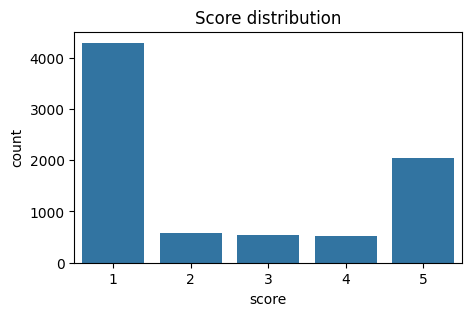

In [3]:
plt.figure(figsize=(5,3))

sns.countplot(x='score',data=df)
plt.title('Score distribution')
plt.show()

In [4]:
df = df[['appId','content','score']]
df.head()

,appId,content,score
0,br.com.brainweb.ifood,"Uso bastante pra fazer mercado, mas, nas últim...",2
1,br.com.brainweb.ifood,Fiz uma compra que tinha desconto e não entrou...,1
2,br.com.brainweb.ifood,"Aplicativo não funciona mais, os pedidos são f...",1
3,br.com.brainweb.ifood,"Quando o carrinho de mercado está muito cheio,...",1
4,br.com.brainweb.ifood,O app é muito bom! O problema é o atendimento....,5


# `Scikit-learn` TfidfVectorizer

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['content']
y = df.score

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

X_train.shape, X_train.toarray()[0][ X_train.toarray()[0] != 0 ], vectorizer.get_feature_names_out()[200:500]

((5600, 5074),
 array([0.13678296, 0.1488778 , 0.10703653, 0.08271516, 0.41034888,
        0.03508129, 0.08525257, 0.11411156, 0.1176131 , 0.05288545,
        0.10703653, 0.09247999, 0.09660478, 0.10703653, 0.07864571,
        0.13409316, 0.08343162, 0.08952975, 0.08145018, 0.03943232,
        0.06947779, 0.10241787, 0.09158497, 0.13409316, 0.06761478,
        0.0605766 , 0.12329144, 0.12329144, 0.11188098, 0.07095144,
        0.10324894, 0.12786948, 0.12468812, 0.06863815, 0.04573934,
        0.04708225, 0.11188098, 0.0421863 , 0.1488778 , 0.14076178,
        0.1262064 , 0.05909218, 0.04661198, 0.11308662, 0.08325899,
        0.05577021, 0.07686276, 0.0486672 , 0.07369704, 0.13678296,
        0.03092096, 0.1488778 , 0.12786948, 0.24937625, 0.04933219,
        0.0994406 , 0.13409316, 0.1488778 , 0.08914624, 0.12329144,
        0.06829031, 0.07928445, 0.41034888, 0.08352065]),
 array(['aconteceram', 'aconteceu', 'acontecido', 'acontecimento',
        'acontesido', 'acordado', 'acordar',

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['content']
y = df.score

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

vectorizer = TfidfVectorizer(ngram_range=(1, 3),max_features=4096)
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

X_train.shape, X_train.toarray()[0][ X_train.toarray()[0] != 0 ], vectorizer.get_feature_names_out()[200:500]

((5600, 4096),
 array([0.13056311, 0.10089592, 0.04279214, 0.11118973, 0.14122185,
        0.10399104, 0.13919323, 0.1434644 , 0.06450964, 0.13734123,
        0.13056311, 0.11280705, 0.11783846, 0.13056311, 0.095932  ,
        0.10176985, 0.1254301 , 0.08240922, 0.10920835, 0.09935289,
        0.04809953, 0.11856004, 0.08474898, 0.14122185, 0.14122185,
        0.12492927, 0.1117153 , 0.08247647, 0.07389131, 0.15039084,
        0.15039084, 0.13647236, 0.08654653, 0.09242644, 0.09643645,
        0.12594301, 0.08372478, 0.05579283, 0.0574309 , 0.10057823,
        0.13647236, 0.05145882, 0.08123371, 0.14468098, 0.17170115,
        0.11280705, 0.12756033, 0.30418902, 0.07208061, 0.08104395,
        0.05685727, 0.13794301, 0.10155928, 0.14018338, 0.06802848,
        0.09375715, 0.05936423, 0.08989562, 0.03771737, 0.07621902,
        0.30418902, 0.06017538, 0.12129759, 0.10874054, 0.15039084,
        0.08330049, 0.15039084, 0.09671113, 0.13121807, 0.10187845]),
 array(['aplicativo já', 'aplic

# `Scikit-learn` KNeighborsClassifier

In [7]:
%%time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

clf = KNeighborsClassifier(metric='cosine')

clf.fit(X_train,y_train)

print(classification_report(y_test, clf.predict(X_test)))

              precision    recall  f1-score   support

           1       0.90      0.92      0.91      1289
           2       0.81      0.74      0.77       177
           3       0.75      0.67      0.71       163
           4       0.72      0.82      0.77       156
           5       0.86      0.84      0.85       615

    accuracy                           0.86      2400
   macro avg       0.81      0.80      0.80      2400
weighted avg       0.86      0.86      0.86      2400

CPU times: user 618 ms, sys: 149 ms, total: 767 ms
Wall time: 834 ms


# `Scikit-learn` Ensemble Models

In [9]:
%%time
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()

clf.fit(X_train,y_train)

print(classification_report(y_test, clf.predict(X_test)))

              precision    recall  f1-score   support

           1       0.99      1.00      1.00      1289
           2       1.00      0.93      0.96       177
           3       0.99      1.00      0.99       163
           4       0.99      0.90      0.94       156
           5       0.96      1.00      0.98       615

    accuracy                           0.99      2400
   macro avg       0.99      0.96      0.97      2400
weighted avg       0.99      0.99      0.99      2400

CPU times: user 6.08 s, sys: 55.7 ms, total: 6.13 s
Wall time: 12.7 s


In [10]:
%%time
from sklearn.ensemble import GradientBoostingClassifier

clf = GradientBoostingClassifier()

clf.fit(X_train,y_train)

print(classification_report(y_test, clf.predict(X_test)))

              precision    recall  f1-score   support

           1       0.87      0.97      0.92      1289
           2       1.00      0.55      0.71       177
           3       1.00      0.56      0.72       163
           4       1.00      0.65      0.79       156
           5       0.84      0.93      0.88       615

    accuracy                           0.88      2400
   macro avg       0.94      0.73      0.80      2400
weighted avg       0.89      0.88      0.87      2400

CPU times: user 31.9 s, sys: 77.6 ms, total: 31.9 s
Wall time: 39.5 s


# `Scikit-learn` MLP

In [11]:
%%time
from sklearn.neural_network import MLPClassifier

clf = MLPClassifier(hidden_layer_sizes=(100,), max_iter=100, alpha=1e-4,
                    solver='sgd', tol=1e-4, random_state=1,
                    learning_rate_init=.1)

clf.fit(X_train, y_train)

print(classification_report(y_test, clf.predict(X_test)))

              precision    recall  f1-score   support

           1       0.99      1.00      1.00      1289
           2       1.00      0.93      0.96       177
           3       0.99      1.00      0.99       163
           4       0.86      0.98      0.92       156
           5       0.99      0.96      0.97       615

    accuracy                           0.98      2400
   macro avg       0.97      0.97      0.97      2400
weighted avg       0.98      0.98      0.98      2400

CPU times: user 32.8 s, sys: 82.7 ms, total: 32.9 s
Wall time: 19.4 s


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


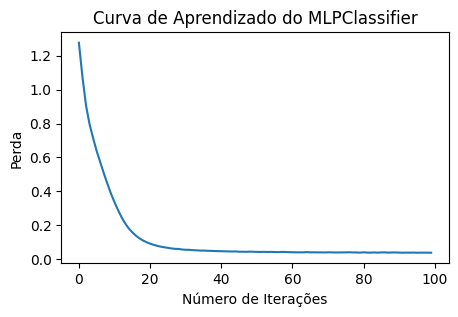

In [12]:
plt.figure(figsize=(5,3))
loss_curve = clf.loss_curve_

plt.plot(loss_curve)
plt.xlabel('Número de Iterações')
plt.ylabel('Perda')
plt.title('Curva de Aprendizado do MLPClassifier')
plt.show()

# Deep Learning

Frameworks de deep learning como o TensorFlow e PyTorch fornecem representação por Tensores, processamento em GPU, Auto Gradiente e otimização por Grafos de Execução, e permitem construir diferentes tipos de rede diferindo bastante do `scikit-learn` que, dentre outras coisas só implementa os modelos perceptron e MLP. Para saber mais você pode acessar https://github.com/Rogerio-mack/Deep-Learning-I.




## Keras TensorFlow

In [13]:
%%time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report # Import classification_report

# Convert y_train and y_test to be 0-indexed for Keras sparse_categorical_crossentropy
y_train_keras = y_train - 1
y_test_keras = y_test - 1

# Define the model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(5, activation='softmax') # 5 classes (0-4)
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train.toarray(), y_train_keras, epochs=10)

# Evaluate the model
y_pred_probs = model.predict(X_test.toarray())

# Get 0-indexed predictions from softmax output and convert back to 1-indexed scores
y_pred = np.argmax(y_pred_probs, axis=1) + 1

# The classification_report needs the original y_test (1-indexed) and the 1-indexed predictions
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6846 - loss: 0.9372
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9379 - loss: 0.2633
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9823 - loss: 0.0854
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9848 - loss: 0.0549
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9843 - loss: 0.0454
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9846 - loss: 0.0417
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9841 - loss: 0.0393
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9855 - loss: 0.0386
Epoch 9/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9864 - loss: 0.0364
Epoch 10/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9848 - loss: 0.0371
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           1       0.99      1.00      1.00  

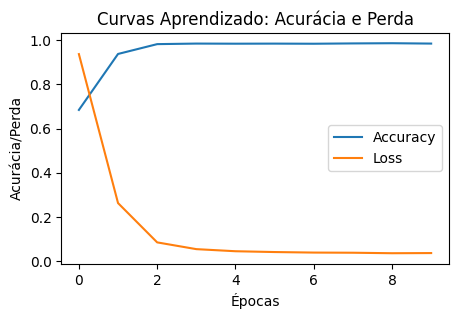

In [14]:
plt.figure(figsize=(5, 3))
plt.plot(history.history['accuracy'],label='Accuracy')
plt.plot(history.history['loss'],label='Loss')
plt.title('Curvas Aprendizado: Acurácia e Perda')
plt.ylabel('Acurácia/Perda')
plt.xlabel('Épocas')
plt.legend()
plt.show()



## PyTorch

In [15]:
%%time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import classification_report

# Se empregar gpu aqui...
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
#
# Para o modelo MLP também
#   model = MLP(input_dim=384, n_classes=n_classes).to(device)
# E os tensores no loop de treino
#   X_batch, y_batch = X_batch.to(device), y_batch.to(device)

# --- Preparação dos dados ---
# Converter sparse matrix para dense e para tensores PyTorch
X_train_tensor = torch.tensor(X_train.toarray(), dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test.toarray(),  dtype=torch.float32)

# PyTorch CrossEntropyLoss espera labels 0-indexed
y_train_tensor = torch.tensor(np.array(y_train - 1), dtype=torch.long)
y_test_tensor  = torch.tensor(np.array(y_test - 1), dtype=torch.long)

# DataLoader para iterar em batches
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

# --- Definição do modelo ---
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 5)   # 5 classes — softmax implícito no loss
        )

    def forward(self, x):
        return self.net(x)

model     = MLP(input_dim=X_train_tensor.shape[1])
criterion = nn.CrossEntropyLoss()          # equivalente ao sparse_categorical_crossentropy
optimizer = optim.Adam(model.parameters())

# --- Treinamento ---
history = {"loss": [], "accuracy": []}  # <-- inicializa antes do loop

epochs = 10
for epoch in range(1, epochs + 1):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(dim=1) == y_batch).sum().item()
        total      += len(y_batch)

    epoch_loss = total_loss / total
    epoch_acc  = correct / total

    history["loss"].append(epoch_loss)        # <-- acumula
    history["accuracy"].append(epoch_acc)     # <-- acumula

    print(f"Epoch {epoch}/{epochs} — loss: {epoch_loss:.4f} — accuracy: {epoch_acc:.4f}")

# --- Avaliação ---
model.eval()
with torch.no_grad():
    logits = model(X_test_tensor)
    y_pred = logits.argmax(dim=1).numpy() + 1   # de volta para 1-indexed

print(classification_report(y_test, y_pred))

Epoch 1/10 — loss: 1.0981 — accuracy: 0.6030
Epoch 2/10 — loss: 0.4538 — accuracy: 0.8375
Epoch 3/10 — loss: 0.1975 — accuracy: 0.9688
Epoch 4/10 — loss: 0.0824 — accuracy: 0.9836
Epoch 5/10 — loss: 0.0542 — accuracy: 0.9841
Epoch 6/10 — loss: 0.0457 — accuracy: 0.9843
Epoch 7/10 — loss: 0.0413 — accuracy: 0.9848
Epoch 8/10 — loss: 0.0389 — accuracy: 0.9857
Epoch 9/10 — loss: 0.0374 — accuracy: 0.9866
Epoch 10/10 — loss: 0.0372 — accuracy: 0.9846
              precision    recall  f1-score   support

           1       0.99      1.00      1.00      1289
           2       1.00      0.93      0.96       177
           3       1.00      0.99      1.00       163
           4       0.99      0.90      0.94       156
           5       0.96      1.00      0.98       615

    accuracy                           0.99      2400
   macro avg       0.99      0.96      0.98      2400
weighted avg       0.99      0.99      0.99      2400

CPU times: user 11.6 s, sys: 900 ms, total: 12.5 s
Wall time

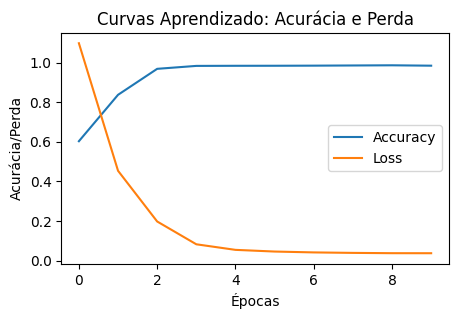

In [16]:
plt.figure(figsize=(5, 3))
plt.plot(history['accuracy'],label='Accuracy')
plt.plot(history['loss'],label='Loss')
plt.title('Curvas Aprendizado: Acurácia e Perda')
plt.ylabel('Acurácia/Perda')
plt.xlabel('Épocas')
plt.legend()
plt.show()



# Embeddings

In [8]:
!pip install transformers sentence-transformers

In [18]:
from sentence_transformers import SentenceTransformer

X = df[['content']]
y = df.score

df_train, df_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Modelo BERT para português (BERTimbau fine-tuned para sentence embeddings)
embedder = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

# Gera embeddings — retorna numpy array (n_amostras, 1024)
X_train_emb = embedder.encode(df_train['content'].tolist(), show_progress_bar=True)
X_test_emb  = embedder.encode(df_test['content'].tolist(),  show_progress_bar=True)

# Converter para tensores
X_train_tensor = torch.tensor(X_train_emb, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_emb,  dtype=torch.float32)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/175 [00:00<?, ?it/s]

Batches:   0%|          | 0/75 [00:00<?, ?it/s]

In [33]:
X_train_emb.shape, X_train_emb[ X_train_emb != 0 ]

((5600, 384),
 array([-0.06523979,  0.08385033, -0.06549539, ..., -0.09680741,
         0.00410906,  0.08925374], dtype=float32))

In [23]:
clf = KNeighborsClassifier(metric='cosine')

clf.fit(X_train_emb,y_train)

print(classification_report(y_test, clf.predict(X_test_emb)))

              precision    recall  f1-score   support

           1       0.93      0.94      0.94      1289
           2       0.84      0.77      0.80       177
           3       0.74      0.68      0.71       163
           4       0.78      0.83      0.80       156
           5       0.93      0.93      0.93       615

    accuracy                           0.90      2400
   macro avg       0.84      0.83      0.84      2400
weighted avg       0.90      0.90      0.90      2400



In [9]:
from transformers import AutoTokenizer, AutoModel
import torch
from torch.utils.data import DataLoader, TensorDataset

# --- 1. Carregar tokenizer e modelo ---
model_name = 'neuralmind/bert-base-portuguese-cased'
tokenizer  = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [14]:
# Inspecione o resultado para entender a estrutura
sample = tokenizer(df['content'].tolist())
print("Chaves retornadas:", sample.keys())

Chaves retornadas: KeysView({'input_ids': [[101, 7026, 22280, 2780, 1174, 1434, 2918, 117, 449, 117, 529, 6764, 678, 1176, 117, 4435, 22279, 7319, 3428, 19311, 119, 231, 16357, 376, 146, 2630, 125, 762, 9760, 4803, 123, 1069, 171, 9379, 117, 1953, 173, 1712, 123, 5076, 596, 117, 449, 625, 2932, 22280, 123, 2925, 125, 18937, 117, 291, 1075, 117, 146, 16357, 4877, 12682, 22278, 122, 117, 625, 1359, 117, 2745, 179, 2779, 3384, 22283, 4081, 22279, 117, 122, 2779, 15212, 179, 3216, 22282, 122, 8671, 944, 259, 3169, 125, 1160, 119, 17911, 22287, 7730, 146, 4576, 117, 126, 22298, 2990, 547, 346, 4395, 684, 146, 179, 14290, 22287, 122, 1257, 1841, 1048, 22281, 236, 122, 5112, 125, 596, 119, 102], [101, 19687, 22305, 230, 6009, 179, 978, 14953, 22280, 122, 346, 3033, 117, 7305, 185, 22283, 346, 4112, 3874, 221, 4503, 122, 8562, 9215, 228, 146, 14953, 22280, 271, 176, 346, 21877, 22281, 236, 117, 346, 1104, 22283, 609, 578, 119, 2781, 4435, 22279, 2394, 1394, 1176, 625, 253, 9358, 2288, 180, 784

In [15]:
print("Shape input_ids:", len(sample['input_ids']))

Shape input_ids: 8000
